# MF_Gates_Plus_FuzzyInput using DOG\nDataset: Lake Erie

In [ ]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
import os
print(f"Process ID (PID): {os.getpid()}")


In [ ]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
import time as _timer_module
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


In [ ]:
# ============================================================
# CPU ONLY Settings (Forced)
# ============================================================
import tensorflow as tf
import platform

try:
    tf.config.set_visible_devices([], 'GPU')
    print('Forcing CPU execution (disabled GPU visibility).')
except RuntimeError as e:
    print(e)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt

# Clear any previous TensorFlow sessions
import tensorflow as tf
tf.keras.backend.clear_session()

from tensorflow.keras import layers
from tensorflow.keras import Model


In [15]:
def gaussian_mf(x, center, sigma=0.5):
    return np.exp(-(x - center)**2 / (2 * sigma**2))

def fuzzy_inference_numpy(x_t, x_tm1):
    mu_low_xt, mu_high_xt = gaussian_mf(x_t, -1.0), gaussian_mf(x_t, 1.0)
    mu_low_xtm1, mu_high_xtm1 = gaussian_mf(x_tm1, -1.0), gaussian_mf(x_tm1, 1.0)

    w1, w2 = mu_low_xt * mu_low_xtm1, mu_low_xt * mu_high_xtm1
    w3, w4 = mu_high_xt * mu_low_xtm1, mu_high_xt * mu_high_xtm1

    y1 = 0.5 * x_t + 0.5 * x_tm1
    y2 = 0.7 * x_t + 0.3 * x_tm1 - 0.1
    y3 = 0.3 * x_t + 0.7 * x_tm1 + 0.1
    y4 = 0.5 * x_t + 0.5 * x_tm1

    return (w1*y1 + w2*y2 + w3*y3 + w4*y4) / (w1 + w2 + w3 + w4 + 1e-8)


In [16]:
def dog(x, mu1=-1.0, mu2=1.0, sigma1=0.5, sigma2=0.5):
    return tf.exp(-tf.square(x - mu1)/ (2 * sigma1**2)) - tf.exp(-tf.square(x - mu2)/ (2 * sigma2**2))

def signed_gaussian(x, sigma=0.5):
    return x * tf.exp(-tf.square(x)/ (2 * sigma**2))

def generalized_bell(x, a=1.0, b=2.0, c_val=0.0):
    return 1.0 / (1.0 + tf.pow(tf.abs((x - c_val) / a), 2*b))

@tf.keras.utils.register_keras_serializable()
class MembershipLSTMSNPCell(layers.Layer):
    def __init__(self, units, mf_type='dog', **kwargs):
        super().__init__(**kwargs)
        self.units, self.mf_type = units, mf_type
        self.state_size, self.output_size = (units, units, units), units
        self.mf = dog if mf_type == 'dog' else signed_gaussian if mf_type == 'sg' else generalized_bell

    def build(self, input_shape):
        input_dim = input_shape[-1]
        self.kernel = self.add_weight(shape=(input_dim, self.units * 4), initializer='glorot_uniform', name='kernel')
        self.recurrent_kernel = self.add_weight(shape=(self.units, self.units * 4), initializer='orthogonal', name='recurrent_kernel')
        self.bias = self.add_weight(shape=(self.units * 4,), initializer='zeros', name='bias')

    def call(self, inputs, states):
        u_tm1 = states[0]  
        z = tf.matmul(inputs, self.kernel) + tf.matmul(u_tm1, self.recurrent_kernel) + self.bias
        z0, z1, z2, z3 = z[:, :self.units], z[:, self.units:2*self.units], z[:, 2*self.units:3*self.units], z[:, 3*self.units:]

        r = tf.tanh(z0)
        c = tf.clip_by_value(self.mf(z1), -1.0, 1.0)
        o = tf.clip_by_value(self.mf(z2), -1.0, 1.0)
        a = tf.tanh(z3)

        u = r * u_tm1 - c * a
        h = o * a
        return h, [u, c, o]

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'mf_type': self.mf_type})
        return config


In [19]:
def build_model(input_dim, units, batch_size):
    cell = MembershipLSTMSNPCell(units, mf_type='dog')
    rnn = layers.RNN(cell, return_sequences=False, return_state=True, stateful=True)

    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x, u_out, c_out, o_out = rnn(inputs)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs=inputs, outputs=[outputs, c_out, o_out])
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(clipnorm=1.0), loss=['mean_squared_error', None, None])
    return model

In [20]:
series = pd.read_csv('../content/monthly-lake-erie-levels-1921-19.csv', header=0, parse_dates=[0], index_col=0)
raw_values = series.values.flatten()

In [21]:
def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)
def timeseries_to_supervised(data, lag):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values


In [22]:

supervised = timeseries_to_supervised(diff_values, 2)
train, test = supervised[:-60], supervised[-60:]
scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

X_train_raw, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
X_test_raw, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]

X_train_fuzzy = np.zeros((X_train_raw.shape[0], 2)); X_test_fuzzy = np.zeros((X_test_raw.shape[0], 2))
for i in range(X_train_raw.shape[0]): X_train_fuzzy[i] = [X_train_raw[i, 1], fuzzy_inference_numpy(X_train_raw[i, 1], X_train_raw[i, 0])]
for i in range(X_test_raw.shape[0]): X_test_fuzzy[i] = [X_test_raw[i, 1], fuzzy_inference_numpy(X_test_raw[i, 1], X_test_raw[i, 0])]

X_train = X_train_fuzzy.reshape((X_train_fuzzy.shape[0], 1, 2))
X_test = X_test_fuzzy.reshape((X_test_fuzzy.shape[0], 1, 2))

all_rmse, all_mse, all_nmse = [], [], []
all_predictions = []
all_losses = []
all_c_means, all_c_stds, all_c_mins, all_c_maxs = [], [], [], []
all_o_means, all_o_stds, all_o_mins, all_o_maxs = [], [], [], []

for run in range(2):
    print(f'\n===== RUN {run+1}/2 =====')
    np.random.seed(run)
    tf.random.set_seed(run)
    tf.keras.backend.clear_session()
    
    model = build_model(input_dim=2, units=8, batch_size=1)
    rnn_layer = model.layers[1]
    
    run_losses = []
    for epoch in range(100):
        history = model.fit(X_train, y_train, epochs=1, batch_size=1, verbose=0, shuffle=False)
        run_losses.append(history.history['loss'][0])
        rnn_layer.reset_states()
    all_losses.append(run_losses)

    # Warmup
    for i in range(len(X_train)): model.predict(X_train[i:i+1], batch_size=1, verbose=0)

    predictions, c_gates, o_gates = [], [], []
    for i in range(len(X_test)):
        yhat, c_val, o_val = model.predict(X_test[i:i+1], batch_size=1, verbose=0)
        c_gates.append(c_val[0])
        o_gates.append(o_val[0])
        
        row = list(X_test_raw[i]) + [yhat[0, 0]]
        inv = scaler.inverse_transform([row])[0, -1] + raw_values[len(train) + i]
        predictions.append(inv)
        
    c_gates, o_gates = np.array(c_gates), np.array(o_gates)
    all_c_means.append(np.mean(c_gates)); all_c_stds.append(np.std(c_gates))
    all_c_mins.append(np.min(c_gates)); all_c_maxs.append(np.max(c_gates))
    all_o_means.append(np.mean(o_gates)); all_o_stds.append(np.std(o_gates))
    all_o_mins.append(np.min(o_gates)); all_o_maxs.append(np.max(o_gates))

    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)
    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f} (Gate Mean C: {np.mean(c_gates):.4f})')

print('\n===== GATE STATISTICS =====')
print(f'C-Gate - Mean: {np.mean(all_c_means):.4f}, Min: {np.min(all_c_mins):.4f}, Max: {np.max(all_c_maxs):.4f}')
print(f'O-Gate - Mean: {np.mean(all_o_means):.4f}, Min: {np.min(all_o_mins):.4f}, Max: {np.max(all_o_maxs):.4f}')
print(f'\nOverall RMSE: {np.mean(all_rmse):.6f}')



===== RUN 1/30 =====
Run 1 — RMSE: 0.483375, MSE: 0.233651, NMSE: 0.0019484044 (Gate Mean C: -0.1220)

===== RUN 2/30 =====
Run 2 — RMSE: 0.458000, MSE: 0.209764, NMSE: 0.0017351085 (Gate Mean C: 0.0798)

===== RUN 3/30 =====
Run 3 — RMSE: 0.470540, MSE: 0.221408, NMSE: 0.0018147606 (Gate Mean C: 0.0049)

===== RUN 4/30 =====
Run 4 — RMSE: 0.468444, MSE: 0.219440, NMSE: 0.0018522861 (Gate Mean C: -0.0290)

===== RUN 5/30 =====
Run 5 — RMSE: 0.460923, MSE: 0.212450, NMSE: 0.0017500192 (Gate Mean C: -0.0495)

===== RUN 6/30 =====
Run 6 — RMSE: 0.453455, MSE: 0.205622, NMSE: 0.0016846862 (Gate Mean C: 0.0373)

===== RUN 7/30 =====
Run 7 — RMSE: 0.465579, MSE: 0.216764, NMSE: 0.0017949610 (Gate Mean C: 0.0170)

===== RUN 8/30 =====
Run 8 — RMSE: 0.472182, MSE: 0.222956, NMSE: 0.0018449319 (Gate Mean C: -0.0438)

===== RUN 9/30 =====
Run 9 — RMSE: 0.462852, MSE: 0.214232, NMSE: 0.0017835565 (Gate Mean C: -0.0400)

===== RUN 10/30 =====
Run 10 — RMSE: 0.476493, MSE: 0.227046, NMSE: 0.001892

## Results

In [23]:
# ============================================================
# Summary Statistics (2 runs)
# ============================================================

print('\n===== FINAL RESULTS — MF_Gates_Plus_FuzzyInput (DOG) on Lake Erie (2 runs) =====')
mean_rmse = np.mean(all_rmse)
std_rmse = np.std(all_rmse)
var_rmse = np.var(all_rmse)

mean_mse = np.mean(all_mse)
std_mse = np.std(all_mse)

mean_nmse = np.mean(all_nmse)
std_nmse = np.std(all_nmse)

print(f'RMSE: {mean_rmse:.6f} ± {std_rmse:.6f} (Var: {var_rmse:.6f})')
print(f'MSE:  {mean_mse:.6f} ± {std_mse:.6f}')
print(f'NMSE: {mean_nmse:.10f} ± {std_nmse:.10f}')

best_idx = np.argmin(all_rmse)

print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.6f}')
print(f'  MSE:  {all_mse[best_idx]:.6f}')
print(f'  NMSE: {all_nmse[best_idx]:.10f}')


===== FINAL RESULTS — MF_Gates_Plus_FuzzyInput (DOG) on Lake Erie (30 runs) =====
RMSE: 0.471830 ± 0.012022 (Var: 0.000145)
MSE:  0.222769 ± 0.011410
NMSE: 0.0018371925 ± 0.0000947129

Best run: 23
  RMSE: 0.444762
  MSE:  0.197813
  NMSE: 0.0016709101


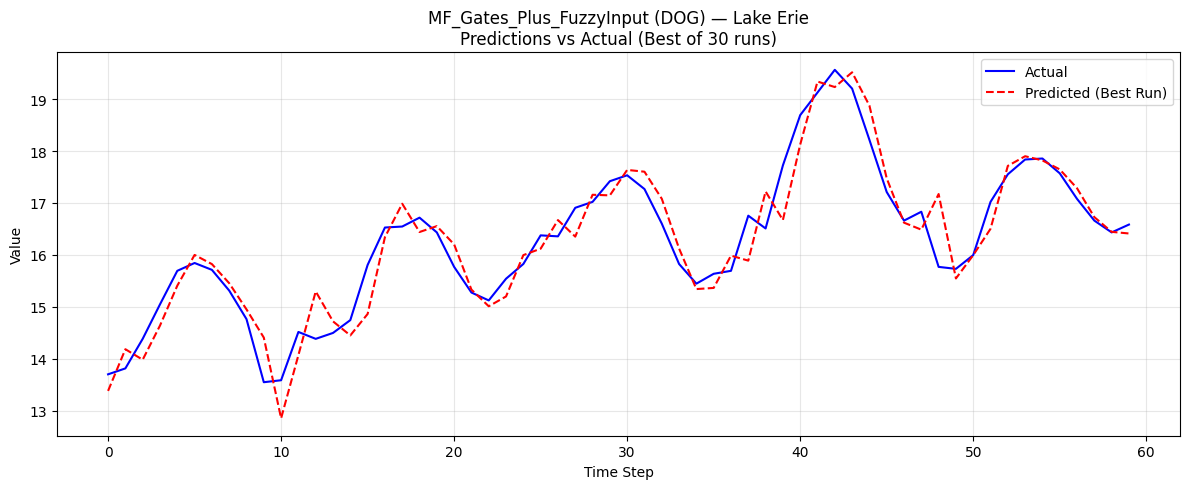

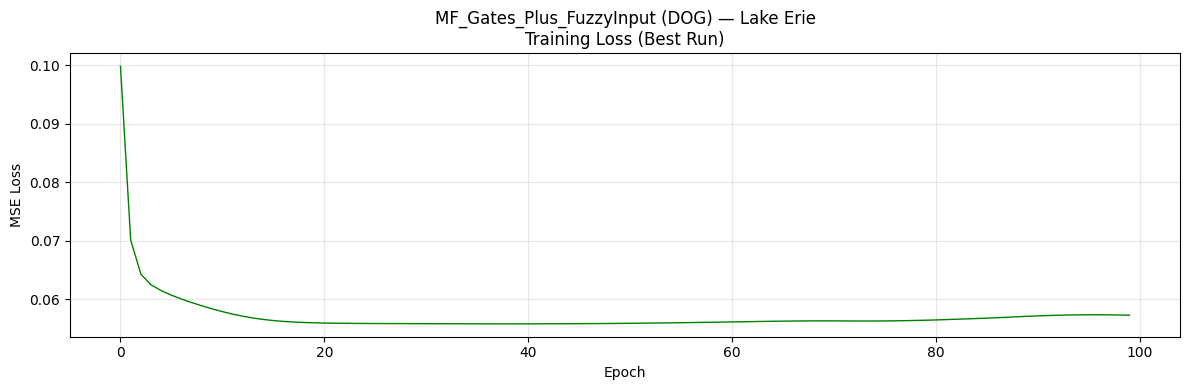

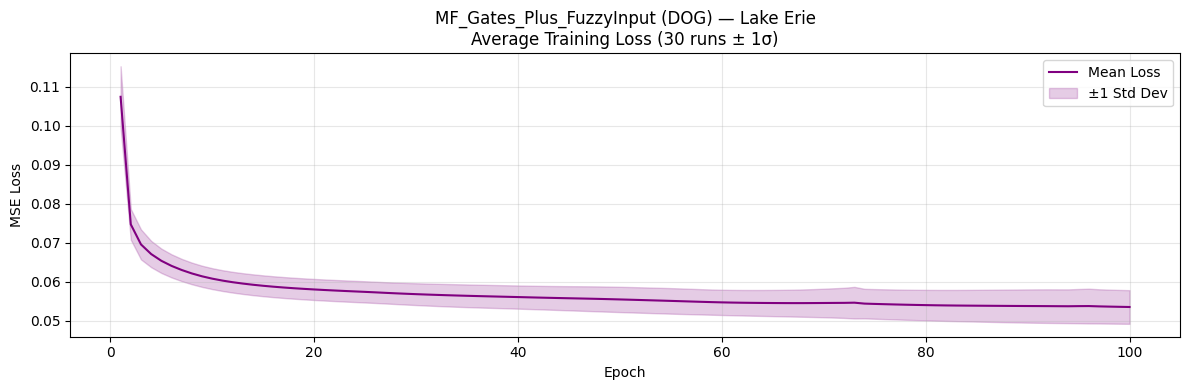

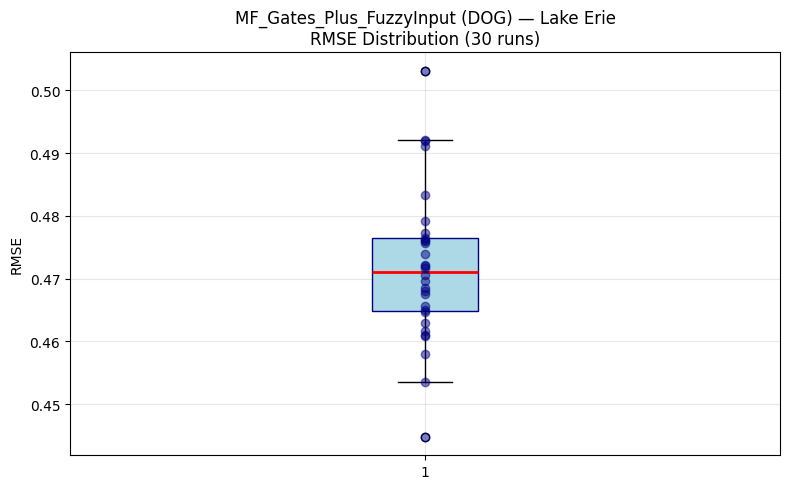

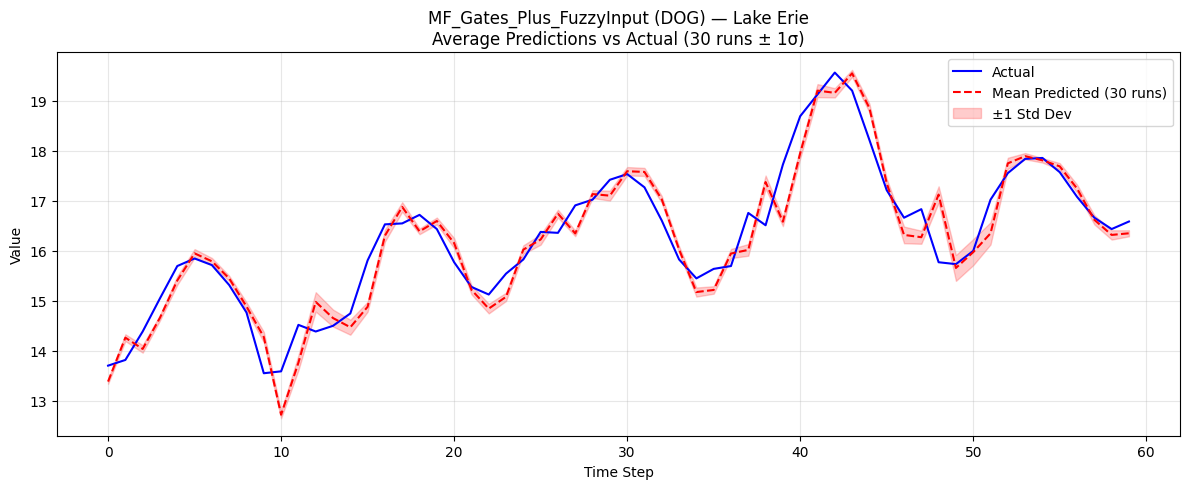

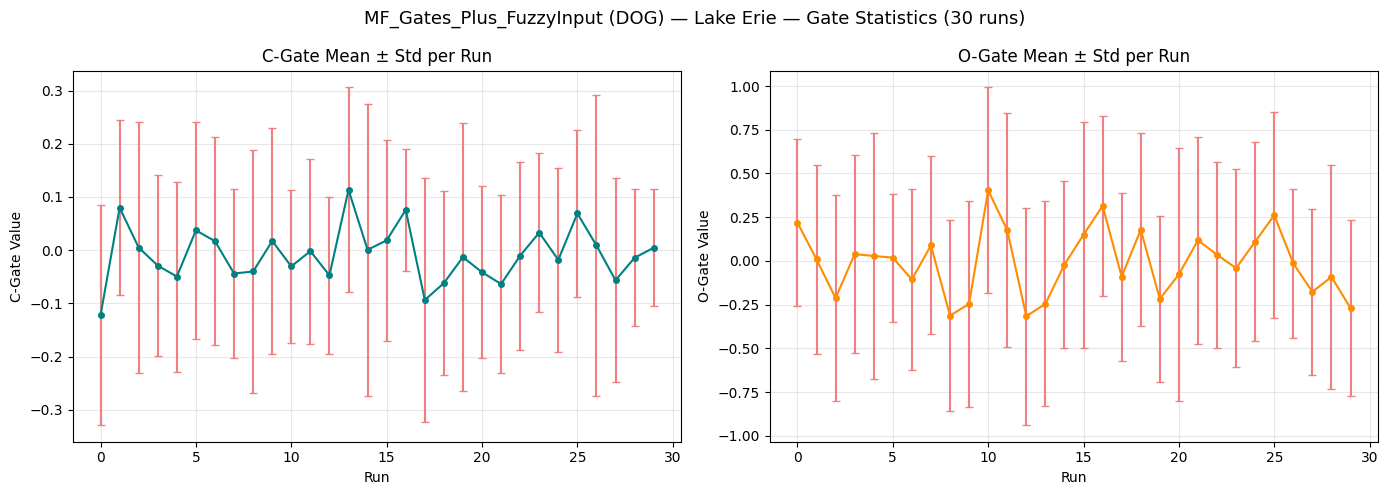

=== Best Run Metrics ===
RMSE: 0.444762
MSE:  0.197813
NMSE: 0.0016709101

=== Average Metrics (30 runs) ===
RMSE: 0.471830 ± 0.012022
MSE:  0.222769 ± 0.011410
NMSE: 0.0018371925 ± 0.0000947129


In [24]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('MF_Gates_Plus_FuzzyInput (DOG) — Lake Erie\nPredictions vs Actual (Best of 2 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('MF_Gates_Plus_FuzzyInput (DOG) — Lake Erie\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Average Loss Curve (All 30 Runs)
# ============================================================

avg_losses = np.mean(all_losses, axis=0)
std_losses = np.std(all_losses, axis=0)
epochs = np.arange(1, len(avg_losses) + 1)

plt.figure(figsize=(12, 4))
plt.plot(epochs, avg_losses, color='purple', linewidth=1.5, label='Mean Loss')
plt.fill_between(epochs, avg_losses - std_losses, avg_losses + std_losses,
                 alpha=0.2, color='purple', label='±1 Std Dev')
plt.title('MF_Gates_Plus_FuzzyInput (DOG) — Lake Erie\nAverage Training Loss (30 runs ± 1σ)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# RMSE Distribution (Boxplot + All Points)
# ============================================================

plt.figure(figsize=(8, 5))
plt.boxplot(all_rmse, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.scatter(np.ones(len(all_rmse)), all_rmse, alpha=0.5, color='navy', zorder=5)
plt.title('MF_Gates_Plus_FuzzyInput (DOG) — Lake Erie\nRMSE Distribution (2 runs)')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Average Predictions vs Actual
# ============================================================

avg_predictions = np.mean(all_predictions, axis=0)
std_predictions = np.std(all_predictions, axis=0)

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(avg_predictions, label='Mean Predicted (2 runs)', color='red',
         linewidth=1.5, linestyle='--')
plt.fill_between(range(len(actual)),
                 avg_predictions - std_predictions,
                 avg_predictions + std_predictions,
                 alpha=0.2, color='red', label='±1 Std Dev')
plt.title('MF_Gates_Plus_FuzzyInput (DOG) — Lake Erie\nAverage Predictions vs Actual (30 runs ± 1σ)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Gate Statistics Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# C-Gate statistics
axes[0].errorbar(range(len(all_c_means)), all_c_means, yerr=all_c_stds,
                 fmt='o-', color='teal', ecolor='lightcoral', capsize=3, markersize=4)
axes[0].set_title('C-Gate Mean ± Std per Run')
axes[0].set_xlabel('Run')
axes[0].set_ylabel('C-Gate Value')
axes[0].grid(True, alpha=0.3)

# O-Gate statistics
axes[1].errorbar(range(len(all_o_means)), all_o_means, yerr=all_o_stds,
                 fmt='o-', color='darkorange', ecolor='lightcoral', capsize=3, markersize=4)
axes[1].set_title('O-Gate Mean ± Std per Run')
axes[1].set_xlabel('Run')
axes[1].set_ylabel('O-Gate Value')
axes[1].grid(True, alpha=0.3)

plt.suptitle('MF_Gates_Plus_FuzzyInput (DOG) — Lake Erie — Gate Statistics (2 runs)', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

print('\n=== Average Metrics (2 runs) ===')
print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')


## Observations

### MF_Gates_Plus_FuzzyInput (DOG) on Lake Erie

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with other variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Average Behaviour**: Compare average predictions vs actual
4. **Gate Dynamics**: Examine C-Gate and O-Gate statistics across runs
5. **Prediction Tracking**: Assess how well predictions track actual values
6. **Computational Cost**: Note training time per run

*After running all variant notebooks, perform cross-variant comparison to evaluate 
whether the membership function activation improves performance over standard activations.*


In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
import time as _timer_module
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
